# Day 12/60 — Rate Limiter (Part 2): Algorithms

## System Design Series

**Topic:** Understanding rate limiting algorithms at a high level helps you choose the right algorithm — or combination of algorithms — to fit specific use cases.

**Five algorithms covered:**
1. **Token Bucket** — allows controlled bursts; used by Amazon, Stripe
2. **Leaky Bucket** — smooths to a fixed outflow rate; used by Shopify
3. **Fixed Window Counter** — simplest; ⚠ boundary spike risk
4. **Sliding Window Log** — exact accuracy; high memory cost
5. **Sliding Window Counter** — hybrid; near-exact at low memory; used by Cloudflare

---

## 1. Setup: Libraries & Colour Palette

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_TOKEN    = '#2980B9'   # blue   — token bucket
C_LEAK     = '#27AE60'   # green  — leaky bucket
C_FIXED    = '#E67E22'   # amber  — fixed window
C_SLIDE    = '#8E44AD'   # purple — sliding window log
C_HYBRID   = '#2E86AB'   # teal   — sliding window counter
C_ALLOW    = '#27AE60'   # green  — allowed request
C_BLOCK    = '#C44E52'   # red    — blocked / dropped
C_GRAY     = '#F8F9FA'
C_ORANGE   = '#DD8452'

print("Libraries loaded. Day 12 ready.")


Libraries loaded. Day 12 ready.


### What this does

Loads Matplotlib and NumPy with the Day 12 colour palette:

| Constant | Colour | Algorithm |
|---|---|---|
| `C_TOKEN` | Blue | Token Bucket |
| `C_LEAK` | Green | Leaky Bucket |
| `C_FIXED` | Amber | Fixed Window Counter |
| `C_SLIDE` | Purple | Sliding Window Log |
| `C_HYBRID` | Teal | Sliding Window Counter |

Each algorithm gets its own consistent colour throughout the notebook.

## 2. Token Bucket Algorithm

> "Token bucket is a container that has a pre-defined capacity. Tokens are put in the bucket at preset rates periodically. Once the bucket is full, no more tokens are added. Each request consumes one token." — Day 12

**Two parameters:**
- **Bucket size (N):** maximum tokens the bucket can hold = maximum burst size
- **Refill rate:** tokens added per second

**How many buckets?** Depends on the rate limiting rules:
- Per-endpoint per-user: e.g. 1 bucket for POST /post, 1 for /friends, 1 for /like
- Per-IP: 1 bucket per IP address
- Global: 1 shared bucket for the whole system (e.g. 10,000 req/s ceiling)

**The burst insight:** Unlike the leaky bucket, token bucket allows up to N requests to be served instantly if tokens are available — short spikes are absorbed.

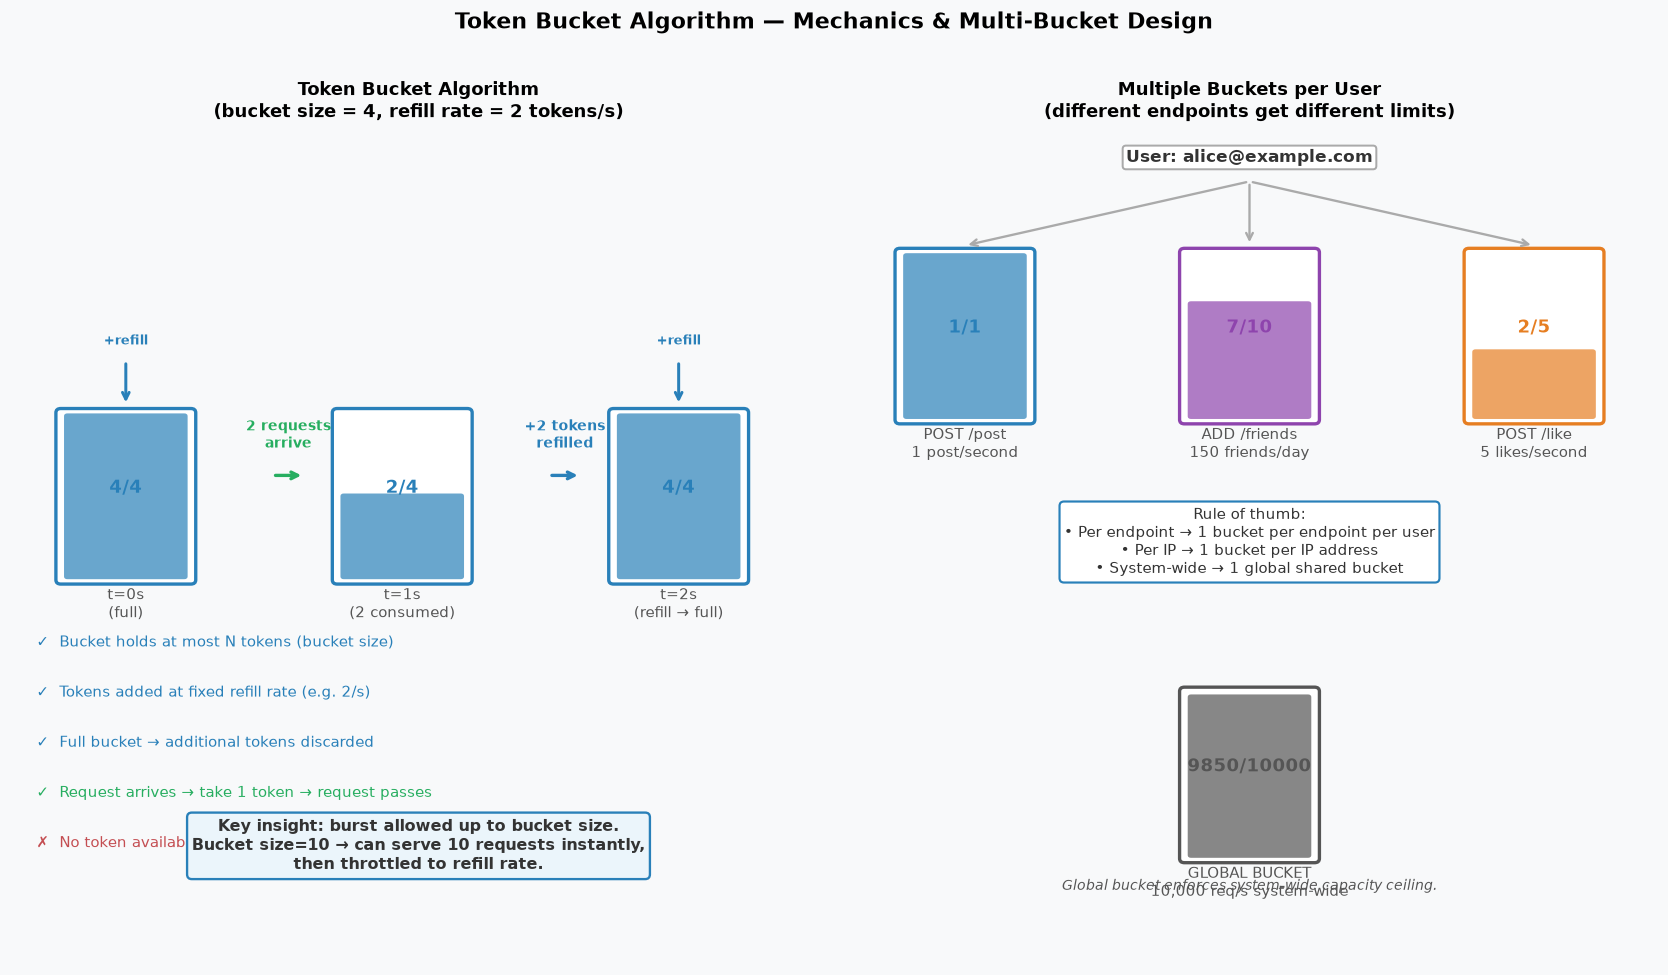

In [2]:
# Token Bucket Algorithm — animated bucket states over time

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

def draw_bucket(ax, cx, cy, capacity, tokens, color, label, refill_arrow=False):
    """Draw a bucket with token fill level."""
    bw, bh = 1.6, 2.4
    # Bucket outline (trapezoid-ish using polygon)
    bx = cx - bw / 2
    # Background container
    r = FancyBboxPatch((bx, cy), bw, bh,
                       boxstyle='round,pad=0.06',
                       facecolor='white', edgecolor=color, lw=2.0)
    ax.add_patch(r)
    # Token fill
    fill_h = (tokens / capacity) * (bh - 0.1)
    if fill_h > 0:
        r2 = FancyBboxPatch((bx + 0.08, cy + 0.05), bw - 0.16, fill_h,
                            boxstyle='round,pad=0.04',
                            facecolor=color, edgecolor='none', alpha=0.7)
        ax.add_patch(r2)
    # Token count
    ax.text(cx, cy + bh / 2 + 0.12, f'{tokens}/{capacity}',
            ha='center', va='center', fontsize=11, fontweight='bold', color=color)
    ax.text(cx, cy - 0.35, label, ha='center', va='center',
            fontsize=9, color='#555')
    if refill_arrow:
        ax.annotate('', xy=(cx, cy + bh + 0.1), xytext=(cx, cy + bh + 0.75),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
        ax.text(cx, cy + bh + 0.98, '+refill', ha='center', fontsize=8,
                color=color, fontweight='bold')

# ── Left: token bucket mechanics ──────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Token Bucket Algorithm\n(bucket size = 4, refill rate = 2 tokens/s)',
             fontsize=11, fontweight='bold')

# Three time snapshots
states = [
    (1.4, 5.5, 4, 4,  C_TOKEN,  't=0s\n(full)',     True),
    (4.8, 5.5, 4, 2,  C_TOKEN,  't=1s\n(2 consumed)', False),
    (8.2, 5.5, 4, 4,  C_TOKEN,  't=2s\n(refill → full)', True),
]
for cx, cy, cap, tok, col, lbl, ref in states:
    draw_bucket(ax, cx, cy, cap, tok, col, lbl, refill_arrow=ref)

# Arrow between states
for x1, x2, msg, col in [(3.2, 3.6, '2 requests\narrive', C_ALLOW),
                          (6.6, 7.0, '+2 tokens\nrefilled',  C_TOKEN)]:
    ax.annotate('', xy=(x2, 7.0), xytext=(x1, 7.0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.0))
    ax.text((x1+x2)/2, 7.4, msg, ha='center', fontsize=8.5,
            color=col, fontweight='bold')

# Algorithm steps
steps = [
    (C_TOKEN, 'Bucket holds at most N tokens (bucket size)'),
    (C_TOKEN, 'Tokens added at fixed refill rate (e.g. 2/s)'),
    (C_TOKEN, 'Full bucket → additional tokens discarded'),
    (C_ALLOW, 'Request arrives → take 1 token → request passes'),
    (C_BLOCK, 'No token available → request dropped immediately'),
]
y0 = 4.6
for col, txt in steps:
    marker = '✓' if col != C_BLOCK else '✗'
    ax.text(0.3, y0, f'{marker}  {txt}', ha='left', va='center',
            fontsize=9, color=col)
    y0 -= 0.72

# Burst handling diagram
ax.text(5.0, 1.35,
        'Key insight: burst allowed up to bucket size.\n'
        'Bucket size=10 → can serve 10 requests instantly,\n'
        'then throttled to refill rate.',
        ha='center', fontsize=9.5, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#EBF5FB',
                  edgecolor=C_TOKEN, lw=1.4))

# ── Right: multiple buckets per user ──────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Multiple Buckets per User\n(different endpoints get different limits)',
             fontsize=11, fontweight='bold')

ax.text(5.0, 11.5, 'User: alice@example.com', ha='center', fontsize=10,
        fontweight='bold', color='#333',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='#aaa', lw=1.2))

bucket_data = [
    (1.5, 7.8, 1,  1, C_TOKEN,  'POST /post\n1 post/second',  ['POST /post']),
    (5.0, 7.8, 10, 7, '#8E44AD','ADD /friends\n150 friends/day',['Add friend (×7)']),
    (8.5, 7.8, 5,  2, '#E67E22','POST /like\n5 likes/second',  ['Like (×2)']),
]
for cx, cy, cap, tok, col, lbl, _reqs in bucket_data:
    draw_bucket(ax, cx, cy, cap, tok, col, lbl)
    ax.annotate('', xy=(cx, cy + 2.5), xytext=(5.0, 11.22),
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.4,
                                connectionstyle='arc3,rad=0.0'))

# Global bucket
draw_bucket(ax, 5.0, 1.5, 10000, 9850, '#555', 'GLOBAL BUCKET\n10,000 req/s system-wide')

ax.text(5.0, 1.05,
        'Global bucket enforces system-wide capacity ceiling.',
        ha='center', fontsize=8.5, color='#555', fontstyle='italic')

ax.text(5.0, 5.6,
        'Rule of thumb:\n'
        '• Per endpoint → 1 bucket per endpoint per user\n'
        '• Per IP → 1 bucket per IP address\n'
        '• System-wide → 1 global shared bucket',
        ha='center', fontsize=9, color='#333',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_TOKEN, lw=1.3))

plt.suptitle('Token Bucket Algorithm — Mechanics & Multi-Bucket Design',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day12_token_bucket.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Token bucket mechanics across 3 time snapshots:**  
At t=0s the bucket is full (4/4 tokens, refill arrow above). At t=1s two requests have consumed 2 tokens (2/4 remaining). At t=2s the bucket is refilled back to full (+2 tokens). Five algorithm steps list the complete logic from token addition to request drop.

**Right — Multiple buckets per user:**  
Alice has three separate buckets: one for POST /post (1/s), one for /friends (150/day), one for /like (5/s). Each bucket tracks independently — using all 5 likes does not affect the post limit. A global bucket at the bottom caps the entire system at 10,000 req/s.

## 3. Token Bucket vs Leaky Bucket

> "Leaky bucket algorithm is same as token bucket except the requests are processed at a fixed rate. It is implemented with a first-in-first-out queue. If the queue is not full, the request is added to the queue. Otherwise, the request is dropped. Requests are pulled from the queue and processed at regular intervals." — Day 12

**Key difference in one sentence:**
Token bucket *releases tokens at a fixed rate* but allows bursts to be served all at once. Leaky bucket *processes requests at a fixed rate* regardless of when they arrived.

**Leaky bucket two parameters:**
- **Bucket size:** queue capacity — requests waiting to be processed
- **Outflow rate:** requests processed per second (fixed)

**Shopify uses leaky bucket** because their merchant APIs call downstream payment processors that cannot handle bursts — a stable, predictable outflow rate is required.

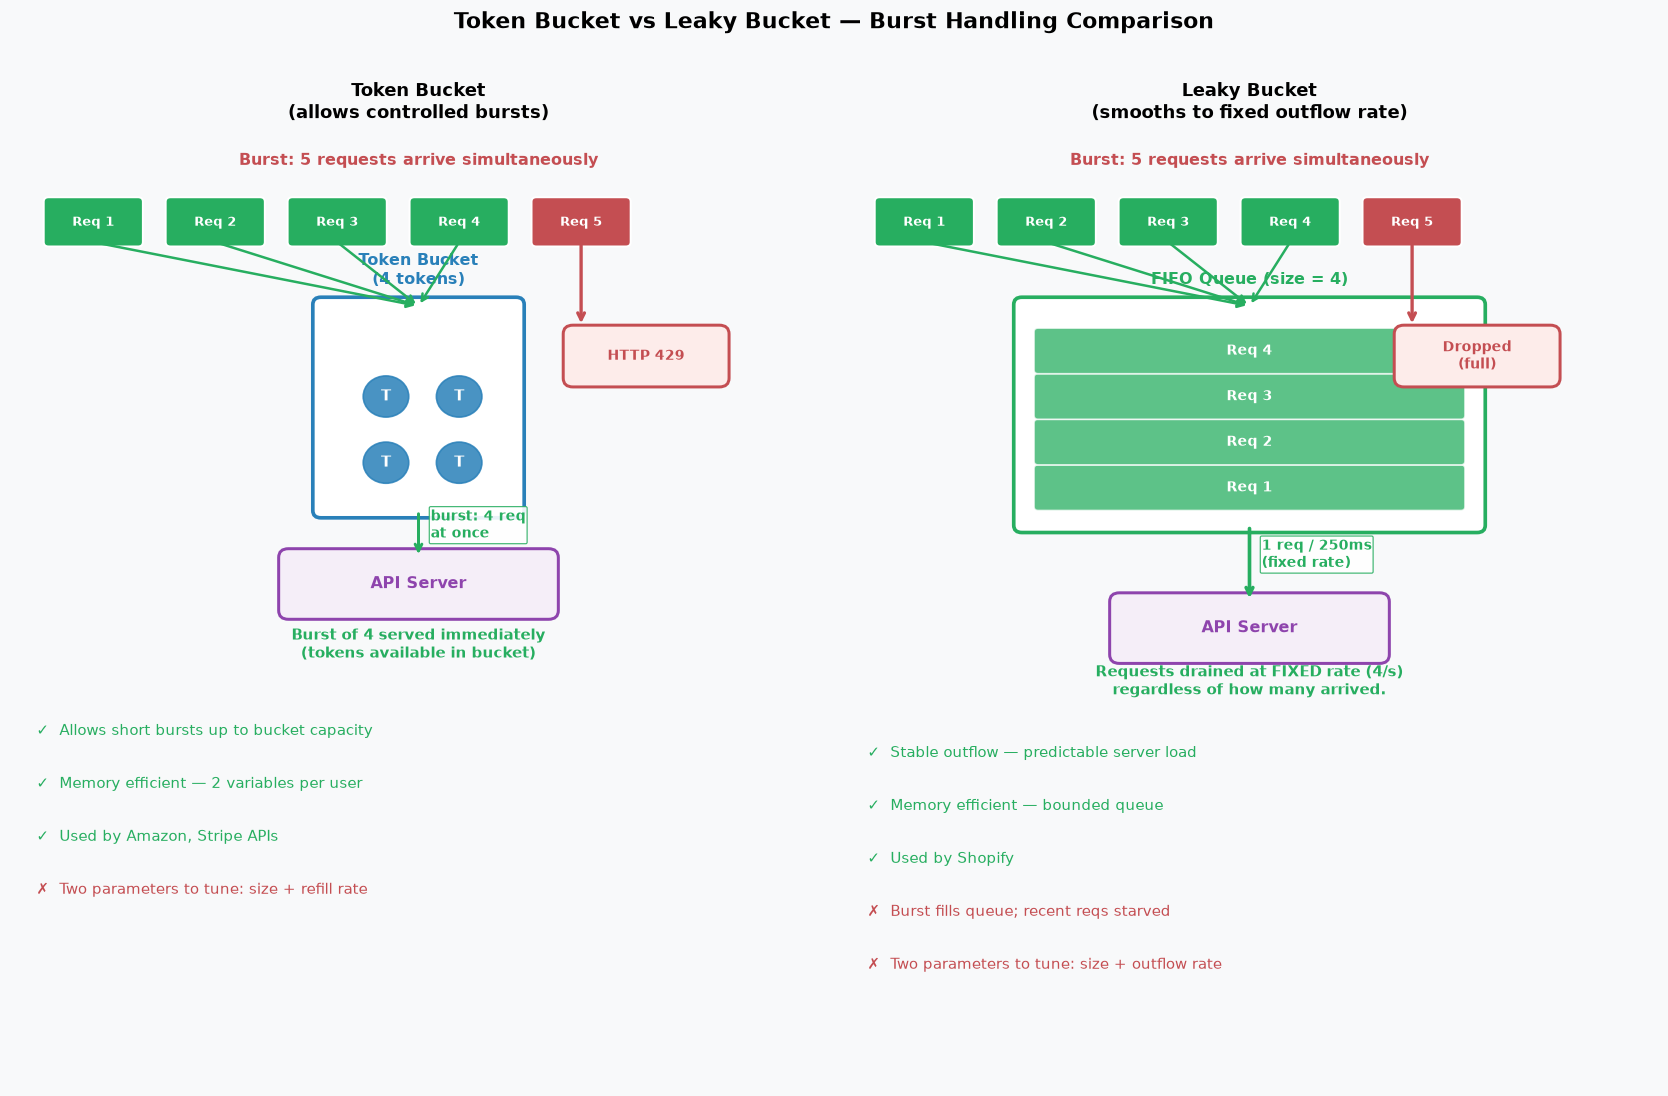

In [3]:
# Token bucket vs Leaky bucket — side by side comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.9)

def arr(ax, x1, y1, x2, y2, label='', color='#555', lw=1.8):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.12
        ax.text(mx, my, label, ha='left', va='center', fontsize=8.5,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.7, alpha=0.9))

# ── Left: Token Bucket — allows bursts ────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Token Bucket\n(allows controlled bursts)',
             fontsize=11, fontweight='bold')

# Incoming requests (bursty)
ax.text(5.0, 12.5, 'Burst: 5 requests arrive simultaneously', ha='center',
        fontsize=9.5, color=C_BLOCK, fontweight='bold')

for i, (rx, lbl) in enumerate([(1.0, 'Req 1'), (2.5, 'Req 2'), (4.0, 'Req 3'),
                                (5.5, 'Req 4'), (7.0, 'Req 5')]):
    col = C_ALLOW if i < 4 else C_BLOCK
    r = FancyBboxPatch((rx - 0.55, 11.45), 1.1, 0.55,
                       boxstyle='round,pad=0.06',
                       facecolor=col, edgecolor='white', lw=1.2)
    ax.add_patch(r)
    ax.text(rx, 11.72, lbl, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')

# Bucket — 4 tokens available
bx, by = 3.8, 7.8
bw, bh = 2.4, 2.8
r = FancyBboxPatch((bx, by), bw, bh,
                   boxstyle='round,pad=0.1',
                   facecolor='white', edgecolor=C_TOKEN, lw=2.2)
ax.add_patch(r)
# Tokens inside
for ti in range(4):
    tx = bx + 0.35 + (ti % 2) * 0.9
    ty = by + 0.3 + (ti // 2) * 0.9
    circle = plt.Circle((tx + 0.45, ty + 0.35), 0.28, color=C_TOKEN, alpha=0.85)
    ax.add_patch(circle)
    ax.text(tx + 0.45, ty + 0.35, 'T', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
ax.text(5.0, 10.88, 'Token Bucket\n(4 tokens)', ha='center', fontsize=9.5,
        fontweight='bold', color=C_TOKEN)

# 4 pass arrows
for rx in [1.0, 2.5, 4.0, 5.5]:
    ax.annotate('', xy=(5.0, 10.58), xytext=(rx, 11.45),
                arrowprops=dict(arrowstyle='->', color=C_ALLOW, lw=1.5))

# Req 5 blocked
ax.annotate('', xy=(7.0, 10.3), xytext=(7.0, 11.45),
            arrowprops=dict(arrowstyle='->', color=C_BLOCK, lw=2.0))
rbox(ax, 7.8, 9.9, 1.8, 0.6, 'HTTP 429', C_BLOCK, bg='#FDECEA', fs=8.5)

# Pass to server (variable rate)
rbox(ax, 5.0, 6.8, 3.2, 0.72, 'API Server', '#8E44AD',
     bg='#F5EEF8', fs=9.5)
arr(ax, 5.0, 7.8, 5.0, 7.16, 'burst: 4 req\nat once', C_ALLOW)

ax.text(5.0, 5.8,
        'Burst of 4 served immediately\n(tokens available in bucket)',
        ha='center', fontsize=9, color=C_ALLOW, fontweight='bold')

pros_cons = [
    (C_ALLOW,  '✓  Allows short bursts up to bucket capacity'),
    (C_ALLOW,  '✓  Memory efficient — 2 variables per user'),
    (C_ALLOW,  '✓  Used by Amazon, Stripe APIs'),
    (C_BLOCK,  '✗  Two parameters to tune: size + refill rate'),
]
y0 = 4.8
for col, txt in pros_cons:
    ax.text(0.3, y0, txt, ha='left', va='center', fontsize=9, color=col)
    y0 -= 0.72

# ── Right: Leaky Bucket — smooths to fixed rate ────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Leaky Bucket\n(smooths to fixed outflow rate)',
             fontsize=11, fontweight='bold')

# Same burst of 5 requests
ax.text(5.0, 12.5, 'Burst: 5 requests arrive simultaneously', ha='center',
        fontsize=9.5, color=C_BLOCK, fontweight='bold')
for i, (rx, lbl) in enumerate([(1.0, 'Req 1'), (2.5, 'Req 2'), (4.0, 'Req 3'),
                                (5.5, 'Req 4'), (7.0, 'Req 5')]):
    col = C_LEAK if i < 4 else C_BLOCK
    r = FancyBboxPatch((rx - 0.55, 11.45), 1.1, 0.55,
                       boxstyle='round,pad=0.06',
                       facecolor=col, edgecolor='white', lw=1.2)
    ax.add_patch(r)
    ax.text(rx, 11.72, lbl, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')

# FIFO Queue (bucket)
qx, qy, qw, qh = 2.2, 7.6, 5.6, 3.0
r = FancyBboxPatch((qx, qy), qw, qh,
                   boxstyle='round,pad=0.1',
                   facecolor='white', edgecolor=C_LEAK, lw=2.2)
ax.add_patch(r)
ax.text(5.0, 10.88, 'FIFO Queue (size = 4)', ha='center',
        fontsize=9.5, fontweight='bold', color=C_LEAK)

# Queue slots
for qi in range(4):
    slot_y = qy + 0.25 + qi * 0.62
    r2 = FancyBboxPatch((qx + 0.2, slot_y), qw - 0.4, 0.52,
                        boxstyle='round,pad=0.05',
                        facecolor=C_LEAK, edgecolor='white', lw=1.0, alpha=0.75)
    ax.add_patch(r2)
    ax.text(5.0, slot_y + 0.26, f'Req {qi+1}', ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')

# Arrows into queue
for rx in [1.0, 2.5, 4.0, 5.5]:
    ax.annotate('', xy=(5.0, 10.58), xytext=(rx, 11.45),
                arrowprops=dict(arrowstyle='->', color=C_LEAK, lw=1.5))

# Req 5 dropped (queue full)
ax.annotate('', xy=(7.0, 10.3), xytext=(7.0, 11.45),
            arrowprops=dict(arrowstyle='->', color=C_BLOCK, lw=2.0))
rbox(ax, 7.8, 9.9, 1.8, 0.6, 'Dropped\n(full)', C_BLOCK, bg='#FDECEA', fs=8.5)

# Steady outflow at fixed rate (drip)
rbox(ax, 5.0, 6.2, 3.2, 0.72, 'API Server', '#8E44AD',
     bg='#F5EEF8', fs=9.5)
arr(ax, 5.0, 7.6, 5.0, 6.56, '1 req / 250ms\n(fixed rate)', C_LEAK, lw=2.2)

ax.text(5.0, 5.3,
        'Requests drained at FIXED rate (4/s)\n'
        'regardless of how many arrived.',
        ha='center', fontsize=9, color=C_LEAK, fontweight='bold')

pros_cons = [
    (C_ALLOW,  '✓  Stable outflow — predictable server load'),
    (C_ALLOW,  '✓  Memory efficient — bounded queue'),
    (C_ALLOW,  '✓  Used by Shopify'),
    (C_BLOCK,  '✗  Burst fills queue; recent reqs starved'),
    (C_BLOCK,  '✗  Two parameters to tune: size + outflow rate'),
]
y0 = 4.5
for col, txt in pros_cons:
    ax.text(0.3, y0, txt, ha='left', va='center', fontsize=9, color=col)
    y0 -= 0.72

plt.suptitle('Token Bucket vs Leaky Bucket — Burst Handling Comparison',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day12_token_vs_leaky.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Token Bucket with burst of 5:**  
Five requests arrive simultaneously. The bucket has 4 tokens. Requests 1–4 (green) immediately consume tokens and are sent to the API server together — the burst is served instantly. Request 5 (red) has no token and gets HTTP 429. Pros/cons list includes the burst-handling note.

**Right — Leaky Bucket with same burst of 5:**  
The same 5 requests arrive. Requests 1–4 join the FIFO queue (queue size = 4). Request 5 is dropped because the queue is full. Requests drain from the queue at a fixed rate (1 req / 250ms = 4/s) — not all at once. The server never sees a burst. Cons note: old requests occupy queue slots; a long burst can starve new arrivals.

## 4. Fixed Window Counter

> "The algorithm divides the timeline into fixed-sized time windows and assigns a counter for each window. Each request increments the counter by one. Once the counter reaches the threshold, new requests are dropped until a new time window starts."

> "Major problem: burst of traffic at the edges of time windows could cause more requests than the allowed quota to go through." — Day 12

**Implementation:** One Redis `INCR` + `EXPIRE` per request. The key is `rate:{user_id}:{window_id}` where `window_id = floor(now / window_size)`.

**The boundary spike problem:**
If the limit is 5 req/minute and a client sends 5 requests in the last few seconds of window 1, then 5 more in the first few seconds of window 2, both sets pass the counter check — but 10 requests were served in roughly 10–15 seconds. The effective rate is 2× the intended limit.

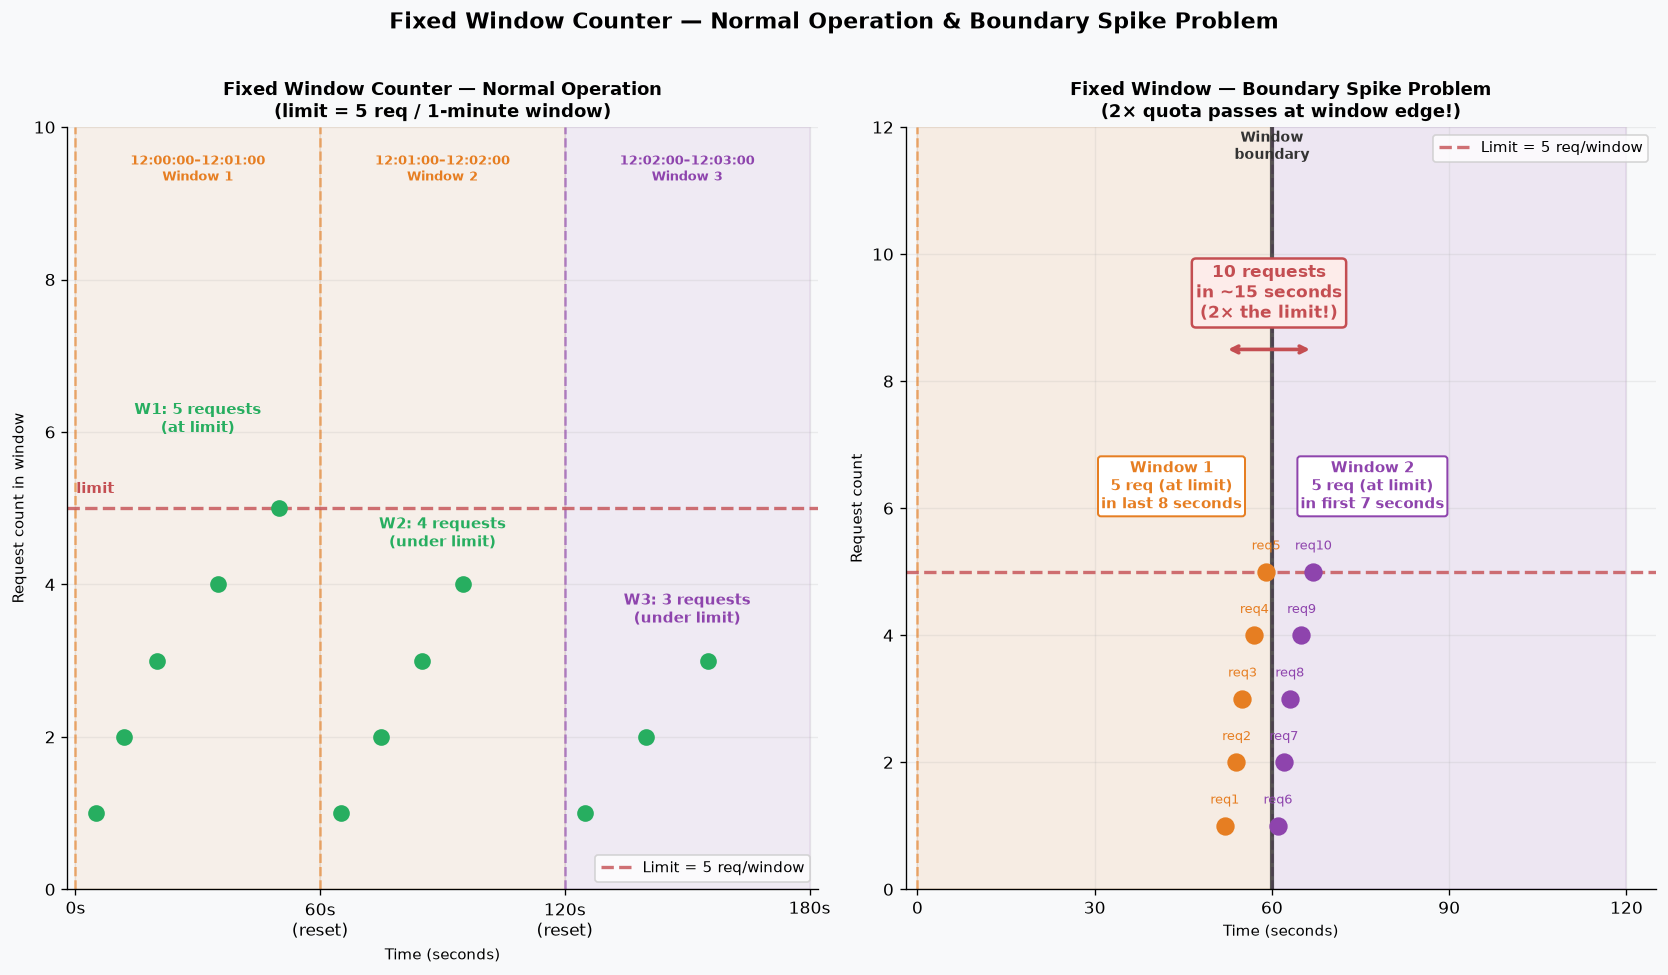

In [4]:
# Fixed Window Counter — mechanics and the boundary spike problem

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

# ── Left: fixed window normal operation ───────────────────────────────────────
ax = axes[0]
ax.set_xlim(-0.5, 10); ax.set_ylim(0, 10)
ax.set_facecolor(C_GRAY)
ax.set_title('Fixed Window Counter — Normal Operation\n(limit = 5 req / 1-minute window)',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Time (seconds)', fontsize=9)
ax.set_ylabel('Request count in window', fontsize=9)

# Three fixed windows
windows = [(0, 60, C_FIXED, '12:00:00–12:01:00\nWindow 1', [5, 12, 20, 35, 50]),
           (60, 120, C_FIXED, '12:01:00–12:02:00\nWindow 2', [65, 75, 85, 95]),
           (120, 180, '#8E44AD', '12:02:00–12:03:00\nWindow 3', [125, 140, 155])]

for (start, end, col, lbl, req_times) in windows:
    ax.axvspan(start, end, alpha=0.08, color=col)
    ax.axvline(start, color=col, lw=1.5, linestyle='--', alpha=0.6)
    count = len(req_times)
    ax.text((start+end)/2, 9.3, lbl, ha='center', fontsize=8,
            color=col, fontweight='bold')
    # Plot requests as dots, building up counter
    for j, t in enumerate(req_times):
        marker = 'o' if j < 5 else 'x'
        c = C_ALLOW if j < 5 else C_BLOCK
        ax.plot(t, j + 1, marker, color=c, ms=9, zorder=3)

# Threshold line
ax.axhline(5, color=C_BLOCK, lw=2.0, linestyle='--', alpha=0.8,
           label='Limit = 5 req/window')
ax.text(9.5, 5.2, 'limit', ha='right', fontsize=9, color=C_BLOCK, fontweight='bold')

# Annotate each window count
ax.text(30, 6.0, 'W1: 5 requests\n(at limit)', ha='center', fontsize=9,
        color=C_ALLOW, fontweight='bold')
ax.text(90, 4.5, 'W2: 4 requests\n(under limit)', ha='center', fontsize=9,
        color=C_ALLOW, fontweight='bold')
ax.text(150, 3.5, 'W3: 3 requests\n(under limit)', ha='center', fontsize=9,
        color='#8E44AD', fontweight='bold')

ax.set_xlim(-2, 182); ax.set_ylim(0, 10)
ax.set_xticks([0, 60, 120, 180])
ax.set_xticklabels(['0s', '60s\n(reset)', '120s\n(reset)', '180s'])
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# ── Right: the boundary spike problem ─────────────────────────────────────────
ax = axes[1]
ax.set_xlim(-0.5, 10); ax.set_ylim(0, 12)
ax.set_facecolor(C_GRAY)
ax.set_title('Fixed Window — Boundary Spike Problem\n(2× quota passes at window edge!)',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Time (seconds)', fontsize=9)
ax.set_ylabel('Request count', fontsize=9)

# Two windows
for start, end, col in [(0, 60, C_FIXED), (60, 120, '#8E44AD')]:
    ax.axvspan(start, end, alpha=0.1, color=col)
    ax.axvline(start, color=col, lw=1.5, linestyle='--', alpha=0.6)

ax.axvline(60, color='#333', lw=2.5, linestyle='-', alpha=0.8)
ax.text(60, 11.5, 'Window\nboundary', ha='center', fontsize=8.5,
        color='#333', fontweight='bold')

# 5 requests just before boundary (55–59s)
spike_before = [52, 54, 55, 57, 59]
for i, t in enumerate(spike_before):
    ax.plot(t, i + 1, 'o', color=C_FIXED, ms=10, zorder=3)
    ax.text(t, i + 1 + 0.35, f'req{i+1}', ha='center', fontsize=7.5,
            color=C_FIXED)

ax.text(43, 6.0, 'Window 1\n5 req (at limit)\nin last 8 seconds',
        ha='center', fontsize=9, color=C_FIXED, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor=C_FIXED, lw=1.2))

# 5 requests just after boundary (61–65s)
spike_after = [61, 62, 63, 65, 67]
for i, t in enumerate(spike_after):
    ax.plot(t, i + 1, 'o', color='#8E44AD', ms=10, zorder=3)
    ax.text(t, i + 1 + 0.35, f'req{i+6}', ha='center', fontsize=7.5,
            color='#8E44AD')

ax.text(77, 6.0, 'Window 2\n5 req (at limit)\nin first 7 seconds',
        ha='center', fontsize=9, color='#8E44AD', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='#8E44AD', lw=1.2))

# Bracket showing 10 requests in 15 seconds
ax.annotate('', xy=(67, 8.5), xytext=(52, 8.5),
            arrowprops=dict(arrowstyle='<->', color=C_BLOCK, lw=2.2))
ax.text(59.5, 9.0, '10 requests\nin ~15 seconds\n(2× the limit!)',
        ha='center', fontsize=10, color=C_BLOCK, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#FDECEA',
                  edgecolor=C_BLOCK, lw=1.5))

ax.axhline(5, color=C_BLOCK, lw=2.0, linestyle='--', alpha=0.8,
           label='Limit = 5 req/window')
ax.set_xlim(-2, 125); ax.set_ylim(0, 12)
ax.set_xticks([0, 30, 60, 90, 120])
ax.legend(fontsize=9); ax.grid(alpha=0.2)

plt.suptitle('Fixed Window Counter — Normal Operation & Boundary Spike Problem',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day12_fixed_window.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Normal operation (3 windows):**  
Each 60-second window is shaded and has its own counter. Request dots plot the growing count. Window 1 hits exactly 5 (green dots). Windows 2 and 3 are under the limit. The threshold line at y=5 is red dashed.

**Right — Boundary spike problem:**  
5 orange dots land in the last ~8 seconds of Window 1 (52–59s). 5 purple dots land in the first ~7 seconds of Window 2 (61–67s). Both sets pass their respective window counters. A red double-headed arrow spans the 15-second period and labels it '10 requests in ~15 seconds (2× the limit!)'. This is the core defect of the fixed window algorithm.

## 5. Sliding Window Log

The sliding window log fixes the boundary spike by tracking exact request timestamps instead of per-window counters.

**How it works:**
1. Each request's timestamp is stored in a **Redis Sorted Set** (score = timestamp)
2. On each new request: `ZADD` the new timestamp
3. `ZREMRANGEBYSCORE` — remove all entries older than `now - window_size`
4. `ZCARD` — count remaining entries = requests in rolling window
5. If count > limit → HTTP 429; else allow

**The memory problem:**
Each request occupies one entry in the sorted set. At 1,000 req/s per user with a 60-second window, that's up to 60,000 timestamps per user — growing linearly with traffic.

**When to use it:** only when exact accuracy is a hard requirement (regulatory, billing, contractual SLA).

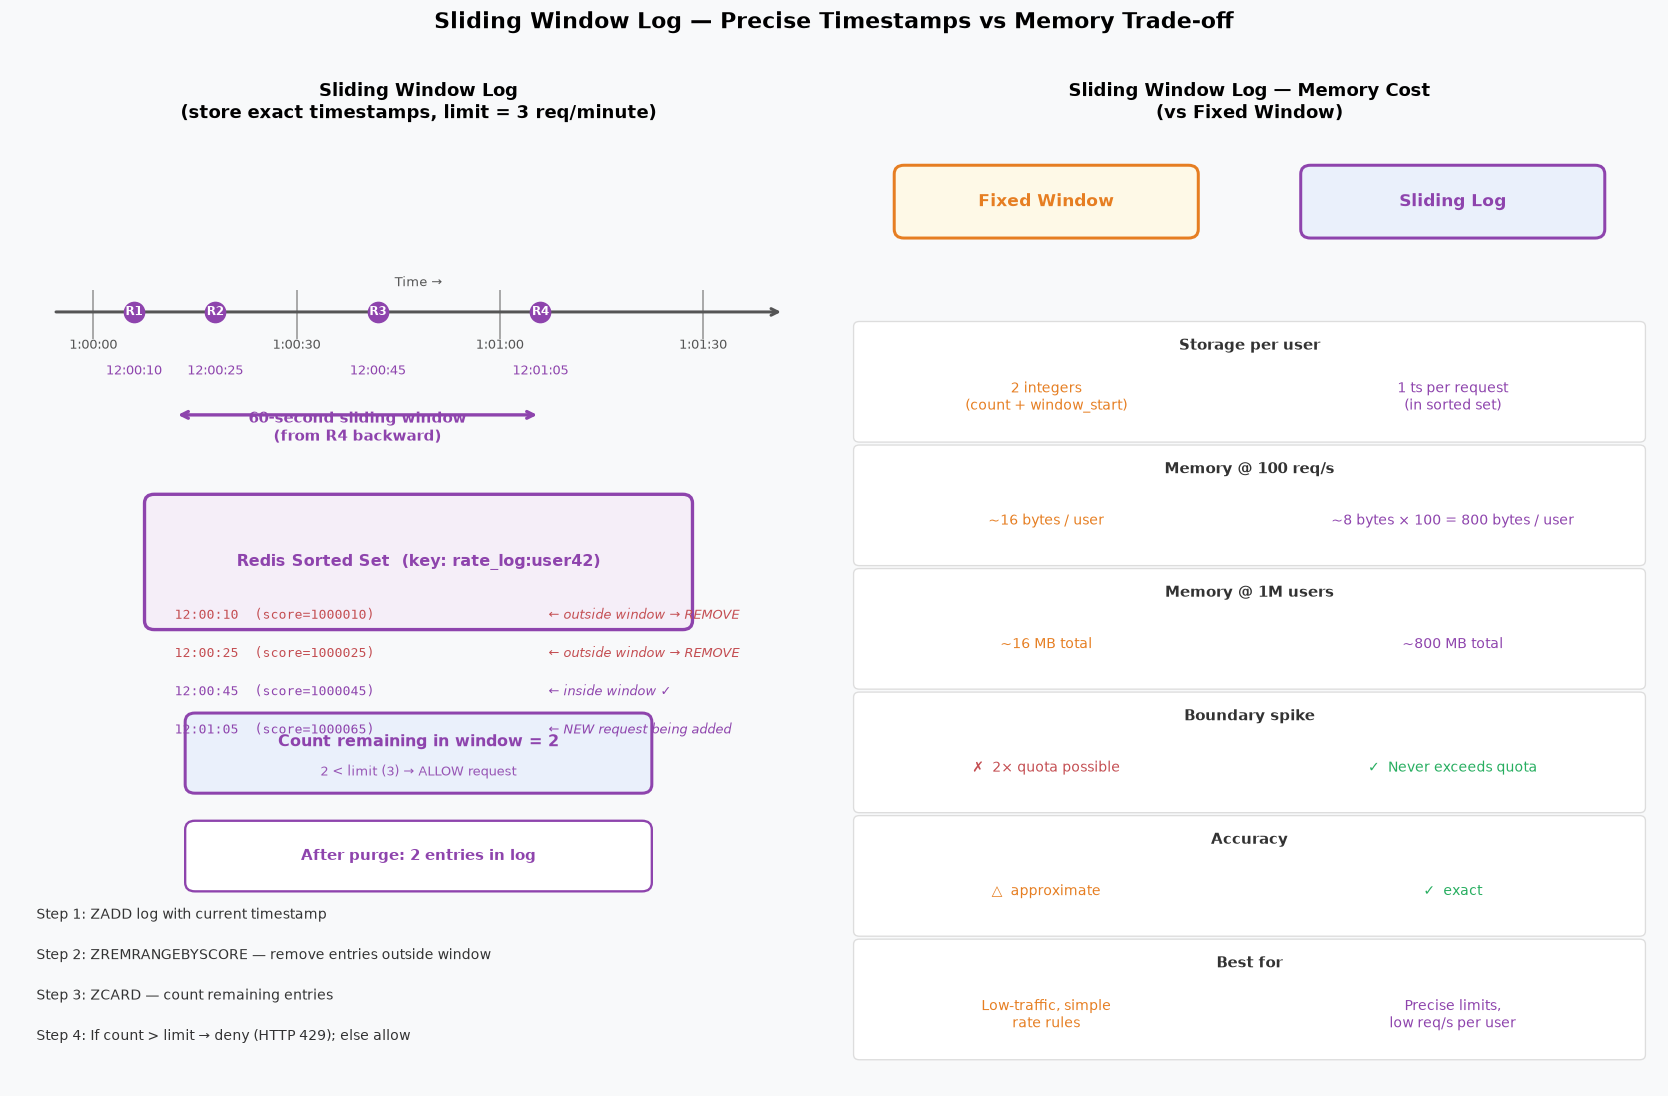

In [5]:
# Sliding Window Log — precise but memory-heavy

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.15 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.25, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.9)

# ── Left: sliding window log mechanics ────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Sliding Window Log\n(store exact timestamps, limit = 3 req/minute)',
             fontsize=11, fontweight='bold')

# Timeline bar
ax.annotate('', xy=(9.5, 10.5), xytext=(0.5, 10.5),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.8))
ax.text(5.0, 10.85, 'Time →', ha='center', fontsize=8, color='#555')
for tick_x, tick_t in [(1.0, '1:00:00'), (3.5, '1:00:30'), (6.0, '1:01:00'),
                       (8.5, '1:01:30')]:
    ax.axvline(tick_x, ymin=0.78, ymax=0.83, color='#aaa', lw=1.2)
    ax.text(tick_x, 10.0, tick_t, ha='center', fontsize=7.5, color='#555')

# Logged requests on the timeline
requests_on_line = [
    (1.5,  '12:00:10', C_SLIDE, 'R1'),
    (2.5,  '12:00:25', C_SLIDE, 'R2'),
    (4.5,  '12:00:45', C_SLIDE, 'R3'),
    (6.5,  '12:01:05', C_SLIDE, 'R4'),   # new request to check
]
for rx, rt, col, lbl in requests_on_line:
    ax.plot(rx, 10.5, 'o', color=col, ms=12, zorder=3)
    ax.text(rx, 10.5, lbl, ha='center', va='center',
            fontsize=7, fontweight='bold', color='white', zorder=4)
    ax.text(rx, 9.65, rt, ha='center', fontsize=7.5, color=col)

# Sliding window bracket at time of R4
ax.annotate('', xy=(6.5, 9.1), xytext=(2.0, 9.1),
            arrowprops=dict(arrowstyle='<->', color=C_SLIDE, lw=2.0))
ax.text(4.25, 8.75, '60-second sliding window\n(from R4 backward)', ha='center',
        fontsize=9, color=C_SLIDE, fontweight='bold')

# Redis sorted-set log
rbox(ax, 5.0, 7.1, 6.5, 1.6, 'Redis Sorted Set  (key: rate_log:user42)',
     C_SLIDE, bg='#F5EEF8', sub='', fs=9.5, lw=2.0)

log_entries = [
    ('12:00:10', 'score=1000010', C_BLOCK,  '  ← outside window → REMOVE'),
    ('12:00:25', 'score=1000025', C_BLOCK,  '  ← outside window → REMOVE'),
    ('12:00:45', 'score=1000045', C_SLIDE,  '  ← inside window ✓'),
    ('12:01:05', 'score=1000065', C_SLIDE,  '  ← NEW request being added'),
]
y0 = 6.38
for ts, score, col, note in log_entries:
    ax.text(2.0, y0, f'{ts}  ({score})', ha='left', va='center',
            fontsize=8, color=col, family='monospace')
    ax.text(6.5, y0, note, ha='left', va='center',
            fontsize=8, color=col, fontstyle='italic')
    y0 -= 0.52

# Decision
rbox(ax, 5.0, 4.5, 5.5, 0.85, 'Count remaining in window = 2',
     C_SLIDE, bg='#EAF0FB', sub='2 < limit (3) → ALLOW request', fs=9.5)

# After purge
rbox(ax, 5.0, 3.1, 5.5, 0.72, 'After purge: 2 entries in log',
     C_SLIDE, bg='white', fs=9, lw=1.4)

steps_text = [
    'Step 1: ZADD log with current timestamp',
    'Step 2: ZREMRANGEBYSCORE — remove entries outside window',
    'Step 3: ZCARD — count remaining entries',
    'Step 4: If count > limit → deny (HTTP 429); else allow',
]
y0 = 2.3
for s in steps_text:
    ax.text(0.3, y0, s, ha='left', va='center', fontsize=8.5, color='#333')
    y0 -= 0.55

# ── Right: memory cost of logging timestamps ──────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Sliding Window Log — Memory Cost\n(vs Fixed Window)',
             fontsize=11, fontweight='bold')

# Comparison: fixed window (cheap) vs sliding log (expensive)
rbox(ax, 2.5, 12.0, 3.5, 0.75, 'Fixed Window', C_FIXED,
     bg='#FEF9E7', fs=10, lw=1.8)
rbox(ax, 7.5, 12.0, 3.5, 0.75, 'Sliding Log', C_SLIDE,
     bg='#EAF0FB', fs=10, lw=1.8)

rows = [
    ('Storage per user',   '2 integers\n(count + window_start)', '1 ts per request\n(in sorted set)'),
    ('Memory @ 100 req/s', '~16 bytes / user', '~8 bytes × 100 = 800 bytes / user'),
    ('Memory @ 1M users',  '~16 MB total', '~800 MB total'),
    ('Boundary spike',     '✗  2× quota possible', '✓  Never exceeds quota'),
    ('Accuracy',           '△  approximate', '✓  exact'),
    ('Best for',           'Low-traffic, simple\nrate rules', 'Precise limits,\nlow req/s per user'),
]

y0 = 11.2
for dim, fv, sv in rows:
    y0 -= 1.68
    r = FancyBboxPatch((0.2, y0 - 0.72), 9.6, 1.5,
                       boxstyle='round,pad=0.07',
                       facecolor='white', edgecolor='#ddd', lw=0.8)
    ax.add_patch(r)
    ax.text(5.0, y0 + 0.52, dim, ha='center', va='center',
            fontsize=9, fontweight='bold', color='#333')
    fv_c = C_ALLOW if '✓' in fv else (C_BLOCK if '✗' in fv else C_FIXED)
    sv_c = C_ALLOW if '✓' in sv else (C_BLOCK if '✗' in sv else C_SLIDE)
    ax.text(2.5, y0 - 0.18, fv, ha='center', va='center', fontsize=8.5, color=fv_c)
    ax.text(7.5, y0 - 0.18, sv, ha='center', va='center', fontsize=8.5, color=sv_c)

plt.suptitle('Sliding Window Log — Precise Timestamps vs Memory Trade-off',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day12_sliding_log.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Sliding window log mechanics:**  
Four requests (R1–R4) placed on a timeline. At t=75s a new request (R4) arrives. The 60-second sliding window bracket slides from R4 backward — it covers 60 seconds ending at now. R1 and R2 fall outside the window and are marked 'REMOVE' (red). R3 and R4 remain (purple). A Redis sorted set box shows the four entries with their scores and removal notes. The decision box shows count=2 < limit=3 → ALLOW.

**Right — Memory cost comparison table:**  
Six-row comparison between Fixed Window and Sliding Log across storage-per-user, memory at 100 req/s, memory at 1M users, boundary spike, accuracy, and best-for. Sliding log wins on accuracy but loses badly on memory at scale.

## 6. Sliding Window Counter (Hybrid Algorithm)

The sliding window counter combines the memory efficiency of fixed window counters with an approximate rolling count to eliminate the boundary spike.

**The formula:**
```
count = W_prev × (1 – position_in_current_window) + W_curr
```
Where `position` is how far (0.0 → 1.0) through the current window the request arrived.

**Example from the post:**
- Previous window (W1) had 8 requests
- Current window (W2) has 5 requests so far
- New request arrives 25% into W2 → position = 0.25
- Estimate = 8 × (1 − 0.25) + 5 = 6 + 5 = **11**
- Limit = 12 → **11 < 12 → ALLOW**

**Memory:** Only 2 integers per user — never grows with traffic volume.

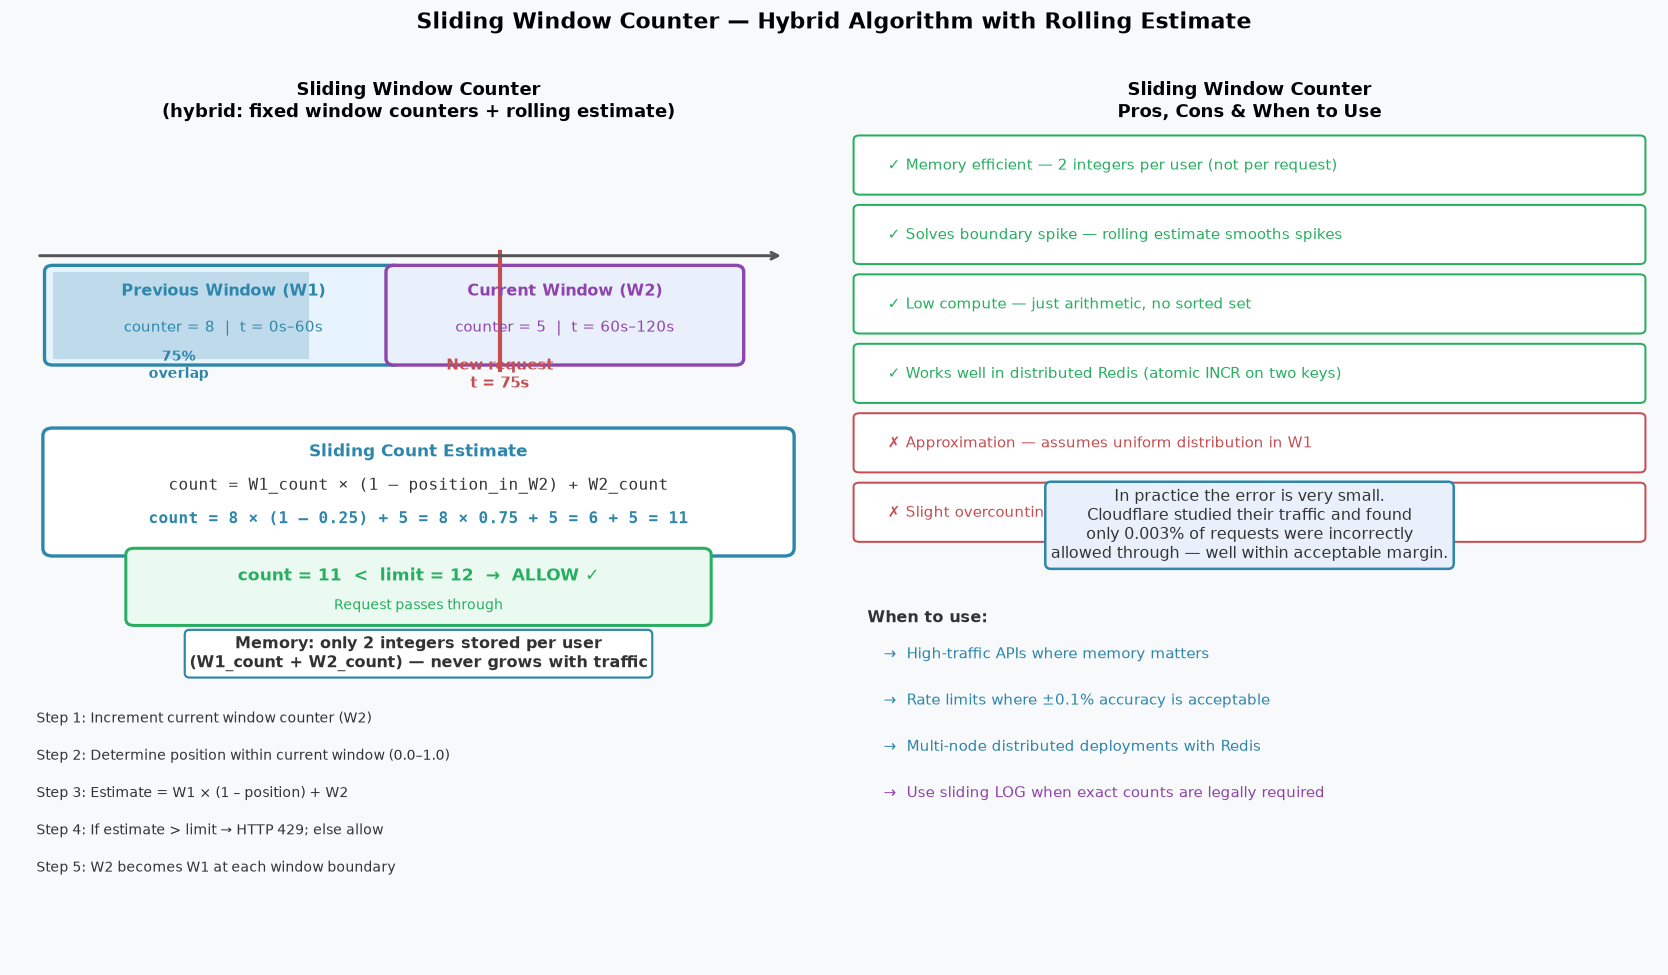

In [6]:
# Sliding Window Counter — the hybrid algorithm

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

# ── Left: sliding window counter calculation ───────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Sliding Window Counter\n(hybrid: fixed window counters + rolling estimate)',
             fontsize=11, fontweight='bold')

# Two fixed windows with counters
# Window 1 (prev): 0–60s  count=8
# Window 2 (curr): 60–120s  count=5
# Request arrives at t=75s (25% into window 2)
# Overlap = (1 - 0.25) × 8 + 5 = 6 + 5 = 11

# Timeline
ax.annotate('', xy=(9.5, 11.0), xytext=(0.3, 11.0),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.8))

# Prev window bar
r1 = FancyBboxPatch((0.5, 9.4), 4.2, 1.35,
                    boxstyle='round,pad=0.1',
                    facecolor='#E8F4FD', edgecolor=C_HYBRID, lw=2.0)
ax.add_patch(r1)
ax.text(2.6, 10.38, 'Previous Window (W1)', ha='center', fontsize=9.5,
        fontweight='bold', color=C_HYBRID)
ax.text(2.6, 9.82, 'counter = 8  |  t = 0s–60s', ha='center', fontsize=9,
        color=C_HYBRID)

# Curr window bar
r2 = FancyBboxPatch((4.7, 9.4), 4.2, 1.35,
                    boxstyle='round,pad=0.1',
                    facecolor='#EAF0FB', edgecolor='#8E44AD', lw=2.0)
ax.add_patch(r2)
ax.text(6.8, 10.38, 'Current Window (W2)', ha='center', fontsize=9.5,
        fontweight='bold', color='#8E44AD')
ax.text(6.8, 9.82, 'counter = 5  |  t = 60s–120s', ha='center', fontsize=9,
        color='#8E44AD')

# Request at t=75s (25% into W2 → 75% of W1 overlaps)
ax.axvline(6.0, ymin=0.71, ymax=0.85, color=C_BLOCK, lw=2.5)
ax.text(6.0, 8.95, 'New request\nt = 75s', ha='center', fontsize=9,
        color=C_BLOCK, fontweight='bold')

# Overlap shading — 75% of W1
r3 = FancyBboxPatch((0.5, 9.4), 3.15, 1.35,
                    boxstyle='square,pad=0',
                    facecolor=C_HYBRID, edgecolor='none', alpha=0.22)
ax.add_patch(r3)
ax.text(2.05, 9.1, '75%\noverlap', ha='center', fontsize=8.5,
        color=C_HYBRID, fontweight='bold')

# Formula box
formula_y = 7.3
r4 = FancyBboxPatch((0.5, formula_y - 0.85), 9.0, 1.75,
                    boxstyle='round,pad=0.12',
                    facecolor='white', edgecolor=C_HYBRID, lw=2.0)
ax.add_patch(r4)
ax.text(5.0, formula_y + 0.58, 'Sliding Count Estimate', ha='center',
        fontsize=10, fontweight='bold', color=C_HYBRID)
ax.text(5.0, formula_y + 0.06,
        'count = W1_count × (1 – position_in_W2) + W2_count',
        ha='center', fontsize=9.5, color='#333', family='monospace')
ax.text(5.0, formula_y - 0.46,
        'count = 8 × (1 – 0.25) + 5 = 8 × 0.75 + 5 = 6 + 5 = 11',
        ha='center', fontsize=9.5, color=C_HYBRID, family='monospace',
        fontweight='bold')

# Decision
limit = 12
rbox_y = 5.8
r5 = FancyBboxPatch((1.5, rbox_y - 0.45), 7.0, 1.0,
                    boxstyle='round,pad=0.1',
                    facecolor='#EAFAF1', edgecolor=C_ALLOW, lw=1.8)
ax.add_patch(r5)
ax.text(5.0, rbox_y + 0.22, f'count = 11  <  limit = {limit}  →  ALLOW ✓',
        ha='center', va='center', fontsize=10, fontweight='bold', color=C_ALLOW)
ax.text(5.0, rbox_y - 0.24, 'Request passes through', ha='center', va='center',
        fontsize=8.5, color=C_ALLOW)

# Memory
ax.text(5.0, 4.6,
        'Memory: only 2 integers stored per user\n'
        '(W1_count + W2_count) — never grows with traffic',
        ha='center', fontsize=9.5, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_HYBRID, lw=1.3))

# Step-by-step
steps = [
    'Step 1: Increment current window counter (W2)',
    'Step 2: Determine position within current window (0.0–1.0)',
    'Step 3: Estimate = W1 × (1 – position) + W2',
    'Step 4: If estimate > limit → HTTP 429; else allow',
    'Step 5: W2 becomes W1 at each window boundary',
]
y0 = 3.8
for s in steps:
    ax.text(0.3, y0, s, ha='left', va='center', fontsize=8.5, color='#333')
    y0 -= 0.58

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.15 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.25, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.9)

# ── Right: sliding counter vs sliding log accuracy ────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Sliding Window Counter\nPros, Cons & When to Use',
             fontsize=11, fontweight='bold')

pros_cons = [
    (C_ALLOW,  '✓ Memory efficient — 2 integers per user (not per request)'),
    (C_ALLOW,  '✓ Solves boundary spike — rolling estimate smooths spikes'),
    (C_ALLOW,  '✓ Low compute — just arithmetic, no sorted set'),
    (C_ALLOW,  '✓ Works well in distributed Redis (atomic INCR on two keys)'),
    (C_BLOCK,  '✗ Approximation — assumes uniform distribution in W1'),
    (C_BLOCK,  '✗ Slight overcounting if W1 was heavily back-loaded'),
]
y0 = 12.4
for col, txt in pros_cons:
    r = FancyBboxPatch((0.2, y0 - 0.38), 9.6, 0.78,
                       boxstyle='round,pad=0.07',
                       facecolor='white', edgecolor=col, lw=1.2)
    ax.add_patch(r)
    ax.text(0.55, y0, txt, ha='left', va='center', fontsize=9, color=col)
    y0 -= 1.08

# Accuracy note
ax.text(5.0, 6.3,
        'In practice the error is very small.\n'
        'Cloudflare studied their traffic and found\n'
        'only 0.003% of requests were incorrectly\n'
        'allowed through — well within acceptable margin.',
        ha='center', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EAF0FB',
                  edgecolor=C_HYBRID, lw=1.5))

# When to use
use_cases = [
    (C_HYBRID,  'High-traffic APIs where memory matters'),
    (C_HYBRID,  'Rate limits where ±0.1% accuracy is acceptable'),
    (C_HYBRID,  'Multi-node distributed deployments with Redis'),
    (C_SLIDE,   'Use sliding LOG when exact counts are legally required'),
]
y0 = 4.8
ax.text(0.3, y0 + 0.5, 'When to use:', fontsize=9.5, fontweight='bold', color='#333')
for col, txt in use_cases:
    ax.text(0.5, y0, f'→  {txt}', ha='left', va='center', fontsize=9, color=col)
    y0 -= 0.72

plt.suptitle('Sliding Window Counter — Hybrid Algorithm with Rolling Estimate',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day12_sliding_counter.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Sliding counter calculation:**  
Two fixed window bars (W1: blue, W2: purple) are shown on a timeline. A vertical red line at t=75s marks where the new request arrives (25% into W2). The 75% overlap region of W1 is shaded — the formula uses that fraction. A formula box shows the full arithmetic step by step. A green decision box confirms 11 < 12 → ALLOW.

**Right — Pros, cons, and when to use:**  
Six cards with colour-coded pros (green) and cons (red). The Cloudflare accuracy note highlights the 0.003% error rate from real-world measurement. A 'when to use' list guides selection vs sliding log.

## 7. Algorithm Comparison Matrix

Choosing the right algorithm depends on your constraints:

| Priority | Best algorithm |
|---|---|
| Allow short bursts | Token Bucket |
| Stable downstream rate | Leaky Bucket |
| Absolute simplicity | Fixed Window |
| Exact accuracy | Sliding Window Log |
| High traffic + balanced | Sliding Window Counter |

Most production systems **combine algorithms**: token bucket per-user (allows bursts) + sliding counter globally (caps total capacity).

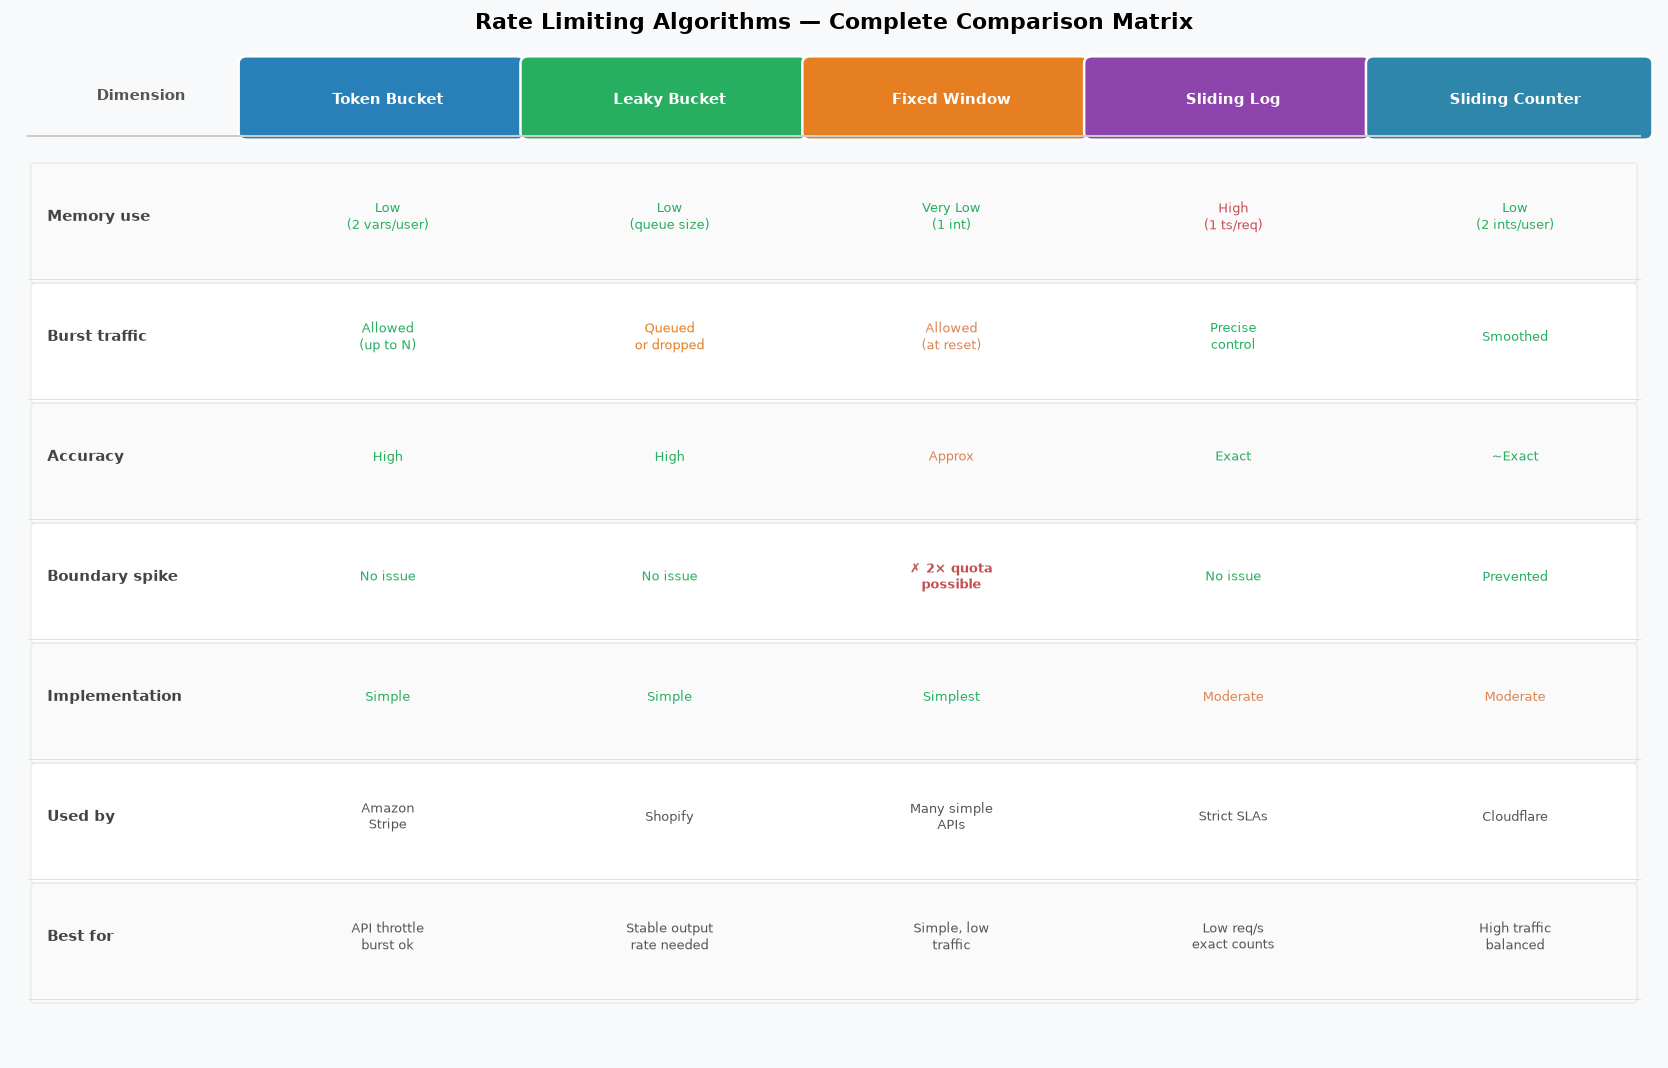

In [7]:
# Algorithm comparison matrix — all 5 algorithms side by side

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)
ax.set_xlim(0, 14); ax.set_ylim(0, 10)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Rate Limiting Algorithms — Complete Comparison Matrix',
             fontsize=13, fontweight='bold')

algos = ['Token Bucket', 'Leaky Bucket', 'Fixed Window', 'Sliding Log', 'Sliding Counter']
algo_colors = [C_TOKEN, C_LEAK, C_FIXED, C_SLIDE, C_HYBRID]

dimensions = [
    'Memory use',
    'Burst traffic',
    'Accuracy',
    'Boundary spike',
    'Implementation',
    'Used by',
    'Best for',
]

cells_data = [
    # Token Bucket
    ['Low\n(2 vars/user)',   'Allowed\n(up to N)',    'High',    'No issue',       'Simple',      'Amazon\nStripe',    'API throttle\nburst ok'],
    # Leaky Bucket
    ['Low\n(queue size)',    'Queued\nor dropped',    'High',    'No issue',       'Simple',      'Shopify',           'Stable output\nrate needed'],
    # Fixed Window
    ['Very Low\n(1 int)',    'Allowed\n(at reset)',   'Approx',  '✗ 2× quota\npossible', 'Simplest', 'Many simple\nAPIs',  'Simple, low\ntraffic'],
    # Sliding Log
    ['High\n(1 ts/req)',     'Precise\ncontrol',      'Exact',   'No issue',       'Moderate',    'Strict SLAs',       'Low req/s\nexact counts'],
    # Sliding Counter
    ['Low\n(2 ints/user)',   'Smoothed',              '~Exact',  'Prevented',      'Moderate',    'Cloudflare',        'High traffic\nbalanced'],
]

rating_map = {
    'Low\n(2 vars/user)': C_ALLOW,
    'Low\n(queue size)': C_ALLOW,
    'Very Low\n(1 int)': C_ALLOW,
    'High\n(1 ts/req)': C_BLOCK,
    'Low\n(2 ints/user)': C_ALLOW,
    'Allowed\n(up to N)': C_ALLOW,
    'Queued\nor dropped': C_FIXED,
    'Allowed\n(at reset)': C_ORANGE,
    'Precise\ncontrol': C_ALLOW,
    'Smoothed': C_ALLOW,
    'High': C_ALLOW, 'Approx': C_ORANGE, 'Exact': C_ALLOW, '~Exact': C_ALLOW,
    'No issue': C_ALLOW,
    '✗ 2× quota\npossible': C_BLOCK,
    'Prevented': C_ALLOW,
    'Simple': C_ALLOW, 'Simplest': C_ALLOW, 'Moderate': C_ORANGE,
}

col_width = 2.4
row_height = 1.18
header_y = 9.4
dim_col_w = 1.8
start_x = 0.2

# Dimension header
ax.text(start_x + dim_col_w / 2, header_y, 'Dimension', ha='center',
        fontsize=9, fontweight='bold', color='#555')
ax.axhline(header_y - 0.35, xmin=0.01, xmax=0.99, color='#ccc', lw=1.2)

# Algorithm headers
for i, (algo, col) in enumerate(zip(algos, algo_colors)):
    hx = start_x + dim_col_w + i * col_width + col_width / 2
    r = FancyBboxPatch((start_x + dim_col_w + i * col_width, header_y - 0.32),
                       col_width - 0.1, 0.68,
                       boxstyle='round,pad=0.07',
                       facecolor=col, edgecolor='white', lw=1.5)
    ax.add_patch(r)
    ax.text(hx, header_y, algo, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

# Rows
for ri, dim in enumerate(dimensions):
    y_top = header_y - 0.68 - ri * row_height
    y_mid = y_top - row_height / 2 + 0.12

    bg = '#FAFAFA' if ri % 2 == 0 else 'white'
    r = FancyBboxPatch((start_x, y_top - row_height + 0.1), 13.6, row_height - 0.08,
                       boxstyle='round,pad=0.04',
                       facecolor=bg, edgecolor='#e8e8e8', lw=0.8)
    ax.add_patch(r)

    ax.text(start_x + 0.1, y_mid, dim, ha='left', va='center',
            fontsize=9, fontweight='bold', color='#444')

    for ci, cell_val in enumerate(cells_data[ci2] for ci2 in range(5)):
        val = cell_val[ri]
        cx = start_x + dim_col_w + ci * col_width + col_width / 2
        text_col = rating_map.get(val, '#555')
        ax.text(cx, y_mid, val, ha='center', va='center',
                fontsize=8, color=text_col, fontweight='bold' if '✗' in val or '✓' in val else 'normal')

    ax.axhline(y_top - row_height + 0.1, xmin=0.01, xmax=0.99, color='#e0e0e0', lw=0.6)

plt.tight_layout()
plt.savefig('/tmp/sd_day12_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


### What this shows

A complete 5×7 comparison matrix — five algorithms as columns, seven dimensions as rows:

- **Memory use** — bytes required per user
- **Burst traffic** — how each algorithm handles a sudden spike
- **Accuracy** — how precisely it enforces the limit
- **Boundary spike** — whether the fixed-window edge problem exists
- **Implementation** — relative complexity
- **Used by** — real-world adopters from the post
- **Best for** — canonical use case

Colour coding: green = advantage, red = disadvantage, amber = neutral/trade-off. The matrix is a self-contained interview reference.

## 8. Architecture Evolution & Algorithm Selector

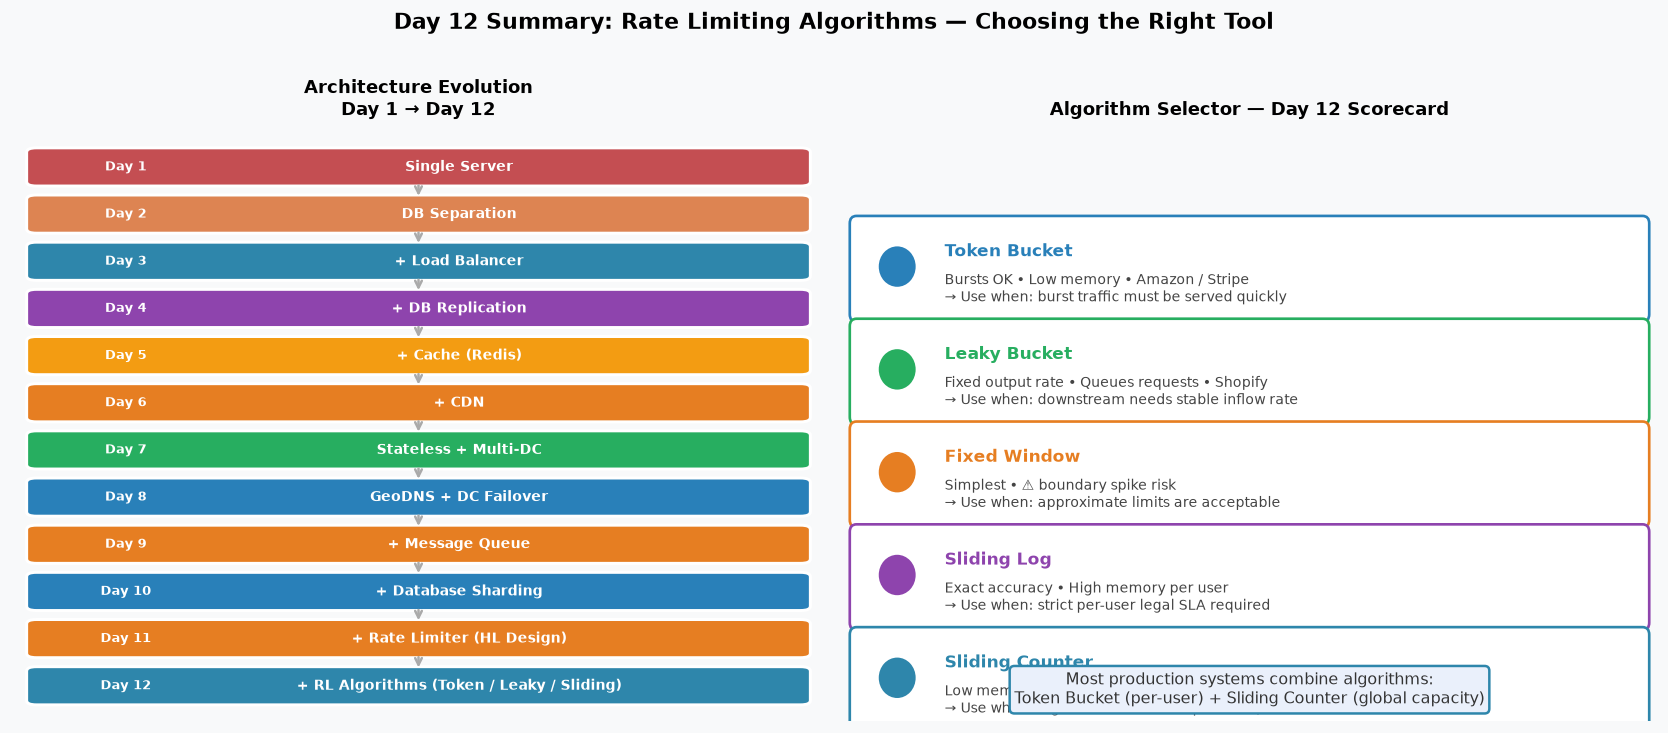

Day 12 complete.


In [8]:
# Day 12 scorecard + evolution Day 1 → 12

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: evolution ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 17)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Architecture Evolution\nDay 1 → Day 12', fontsize=11, fontweight='bold')

days = [
    ('Day 1',  'Single Server',                    '#C44E52'),
    ('Day 2',  'DB Separation',                    '#DD8452'),
    ('Day 3',  '+ Load Balancer',                  '#2E86AB'),
    ('Day 4',  '+ DB Replication',                 '#8E44AD'),
    ('Day 5',  '+ Cache (Redis)',                  '#F39C12'),
    ('Day 6',  '+ CDN',                            '#E67E22'),
    ('Day 7',  'Stateless + Multi-DC',             '#27AE60'),
    ('Day 8',  'GeoDNS + DC Failover',             '#2980B9'),
    ('Day 9',  '+ Message Queue',                  '#E67E22'),
    ('Day 10', '+ Database Sharding',              '#2980B9'),
    ('Day 11', '+ Rate Limiter (HL Design)',       '#E67E22'),
    ('Day 12', '+ RL Algorithms (Token / Leaky / Sliding)', C_HYBRID),
]
ys = np.linspace(15.8, 1.0, len(days))
for i, ((day, label, color), y) in enumerate(zip(days, ys)):
    r = FancyBboxPatch((0.3, y - 0.42), 9.4, 0.85,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(1.4, y, day, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white')
    ax.text(5.5, y, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    if i < len(days) - 1:
        ax.annotate('', xy=(5, ys[i+1] + 0.43), xytext=(5, y - 0.43),
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))

# ── Right: scorecard for each algorithm ──────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 12); ax.set_ylim(0, 8)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Algorithm Selector — Day 12 Scorecard', fontsize=11, fontweight='bold')

algo_summary = [
    (C_TOKEN,  'Token Bucket',
     'Bursts OK • Low memory • Amazon / Stripe\n→ Use when: burst traffic must be served quickly'),
    (C_LEAK,   'Leaky Bucket',
     'Fixed output rate • Queues requests • Shopify\n→ Use when: downstream needs stable inflow rate'),
    (C_FIXED,  'Fixed Window',
     'Simplest • ⚠ boundary spike risk\n→ Use when: approximate limits are acceptable'),
    (C_SLIDE,  'Sliding Log',
     'Exact accuracy • High memory per user\n→ Use when: strict per-user legal SLA required'),
    (C_HYBRID, 'Sliding Counter',
     'Low memory + near-exact • Cloudflare\n→ Use when: high traffic, balanced precision/cost'),
]

y0 = 7.4
for (col, name, summary) in algo_summary:
    y0 -= 1.38
    r = FancyBboxPatch((0.2, y0 - 0.56), 11.6, 1.22,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=col, lw=1.6)
    ax.add_patch(r)
    circle = plt.Circle((0.8, y0 + 0.08), 0.26, color=col, zorder=3)
    ax.add_patch(circle)
    ax.text(1.5, y0 + 0.28, name, ha='left', va='center',
            fontsize=10, fontweight='bold', color=col)
    ax.text(1.5, y0 - 0.22, summary, ha='left', va='center',
            fontsize=8.5, color='#444')

ax.text(6.0, 0.42,
        'Most production systems combine algorithms:\n'
        'Token Bucket (per-user) + Sliding Counter (global capacity)',
        ha='center', va='center', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#EAF0FB',
                  edgecolor=C_HYBRID, lw=1.5))

plt.suptitle('Day 12 Summary: Rate Limiting Algorithms — Choosing the Right Tool',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day12_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Day 12 complete.")


### What this shows

**Left — Evolution Day 1 → Day 12:**  
Day 12 completes the Rate Limiter topic (Parts 1 + 2). The 12-day stack now covers the full foundational layer from single server to horizontally sharded, geo-distributed, message-queued, and rate-limited architecture.

**Right — Algorithm Selector Scorecard:**  
Five cards — one per algorithm — each with a one-line summary and a '→ Use when:' prescription:

- **Token Bucket** → bursts are acceptable, want simple implementation
- **Leaky Bucket** → downstream needs a stable, predictable inflow rate
- **Fixed Window** → approximate limits are fine, simplicity is paramount
- **Sliding Log** → strict per-user legal SLA with exact counts required
- **Sliding Counter** → high traffic, want near-exact accuracy at low memory cost

The takeaway box at the bottom reinforces the combination pattern: most real systems run token bucket per-user plus sliding counter globally.

## AWS Production Notes

> Based on the AWS Well-Architected Framework and AWS official documentation.

---

### Critical Corrections

| Claim in This Notebook | Correction |
|---|---|
| 'Amazon uses token bucket' — attributed without qualification | **Amazon API Gateway** specifically uses token bucket for HTTP throttling (Burst Limit = bucket size, Rate Limit = refill rate). AWS SDK client-side retry uses **exponential backoff with jitter** — not a token bucket. Both exist in the Amazon ecosystem but serve opposite roles (server-side limiting vs client-side retry). |
| INCR + EXPIRE sequence presented as baseline pattern | If the process crashes after INCR but before EXPIRE, the key never expires and the user is **permanently blocked**. The correct atomic pattern is `SET key 1 EX ttl NX` (for first-time set) or a Lua script. See Day 11's AWS notes for the Lua script. |
| 'Redis Cluster as the single shared counter store' (implied) | Correct direction, but: in Redis Cluster Mode, **Lua EVAL scripts can only access keys that hash to the same slot**. Previous-window and current-window counter keys for the same user may hash to different slots, causing a **CROSSSLOT error**. Fix: use hash tags. |

---

### API Gateway Token Bucket: The Real Settings

```
API Gateway Rate Limiting Settings:
  Burst Limit  = token bucket CAPACITY (max instantaneous requests)
  Rate Limit   = token REFILL rate (RPS)

Example: Rate=1000, Burst=2000
  → Bucket holds 2000 tokens
  → Refills at 1000 tokens/second
  → A burst of 2000 requests succeeds; 2001st is throttled (429)
  → After 1s, 1000 tokens added → 1000 more requests allowed

Per-client throttling: Use Usage Plans + API Keys
Account defaults: Rate=10000, Burst=5000 (requestable increase via Service Quotas)
```

---

### AWS WAF Native Sliding Window

AWS WAF rate-based rules implement a sliding window counter natively:

```
Rule: Rate-Based
  Window: 5 minutes (300s) or 30 seconds
  Threshold: N requests per window per aggregation key
  Aggregation keys: IP, forwarded IP, HTTP header, URI path, query string, HTTP method

No code required — no Redis, no Lua scripts, no infra to manage
Runs at CloudFront edge or ALB, before traffic enters your application
```

---

### ElastiCache Cluster Mode: Hash Tag Requirement

```lua
-- In Redis Cluster Mode: Lua scripts can only access keys on the same slot
-- Problem: These two keys may hash to DIFFERENT slots → CROSSSLOT error
local prev_window_key = 'rate:user123:window:1'
local curr_window_key = 'rate:user123:window:2'

-- Fix: Use hash tags {} to force both keys to the same slot
-- The part inside {} is used for slot assignment
local prev_window_key = 'rate:{user123}:window:1'  -- hash tag: {user123}
local curr_window_key = 'rate:{user123}:window:2'  -- same hash tag → same slot

-- Now both keys hash to the same slot; Lua EVAL works correctly
```

> **Apply hash tags to ALL rate limit key names** before deploying to ElastiCache Cluster Mode Enabled.

---

### Algorithm Cost at Scale: Memory vs Accuracy

| Algorithm | Memory per User | At 1M Users | AWS Cost |
|---|---|---|---|
| **Sliding Window Log** | ~800 bytes | ~800 MB | ~$7.50/month (ElastiCache r7g.large) |
| **Sliding Window Counter** | ~16 bytes | ~16 MB | ~$0.15/month |
| **Token Bucket** | ~40 bytes | ~40 MB | ~$0.38/month |

> Sliding Window Log vs Counter is a **20× cost difference** at scale — algorithm selection has direct cost impact.

---

### Client-Side: Exponential Backoff with Jitter

```python
import random, time

def retry_with_jitter(func, max_retries=5, base_delay=0.1):
    for attempt in range(max_retries):
        try:
            return func()
        except RateLimitError as e:
            if attempt == max_retries - 1:
                raise
            # Full jitter: random between 0 and exponential cap
            delay = random.uniform(0, base_delay * (2 ** attempt))
            time.sleep(delay)
```

> Without jitter, synchronized clients create **thundering-herd retry storms** that re-trigger rate limiting.
> AWS SDKs implement this automatically; custom clients must implement it explicitly.

---

### Well-Architected Checklist

- [ ] **PERF 1** — Layer rate limiting: WAF (edge) → API Gateway (managed) → ElastiCache (custom)
- [ ] **SEC 6** — AWS WAF rate-based rules for IP-level blocking at CloudFront/ALB edge
- [ ] **REL 10** — All ElastiCache Cluster Mode rate limit keys use hash tags `{user_id}`
- [ ] **REL 9** — Atomic counter init: `SET key 1 EX ttl NX` or Lua script (never INCR + EXPIRE as two commands)
- [ ] **COST 4** — Choose algorithm based on accuracy requirement; Sliding Window Counter is 20× cheaper than Log at 1M users
- [ ] **OPS 7** — CloudWatch: `ThrottleCount`, `BlockedRequests`; X-Ray: trace throttled requests
